In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [4]:
df=pd.read_csv('gld_price_data.csv')
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

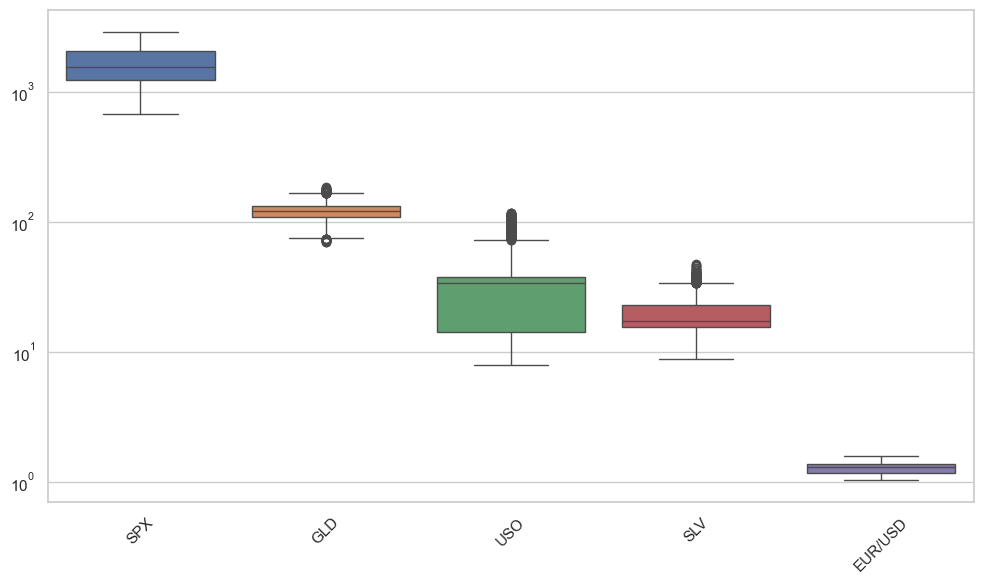

In [9]:
sns.set(style="whitegrid")

# Ajuster la taille de la figure pour une meilleure lisibilité
plt.figure(figsize=(10, 6))

# Créer un boxplot pour chaque variable numérique
ax = sns.boxplot(data=df, orient="v")

# Utiliser une échelle logarithmique pour les valeurs en y (pour gérer les écarts de valeurs comme le loyer)
ax.set_yscale('log')

# Améliorer la mise en page
plt.xticks(rotation=45)
plt.tight_layout()

# Afficher le graphique
plt.show()

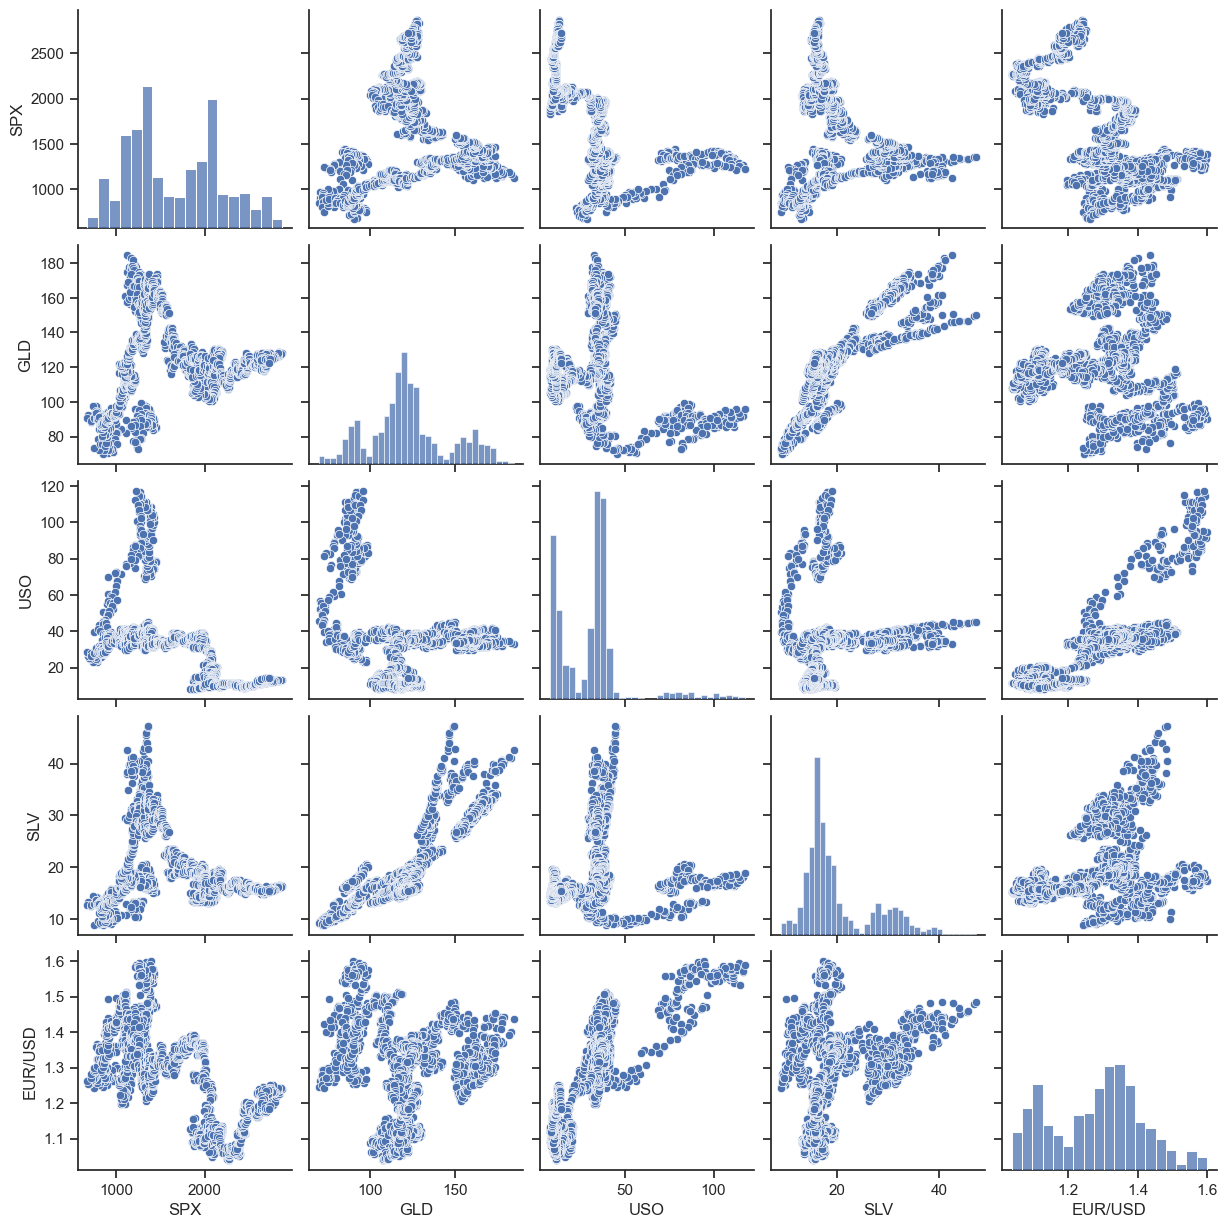

In [10]:
sns.set(style="ticks")
sns.pairplot(df)

<Axes: >

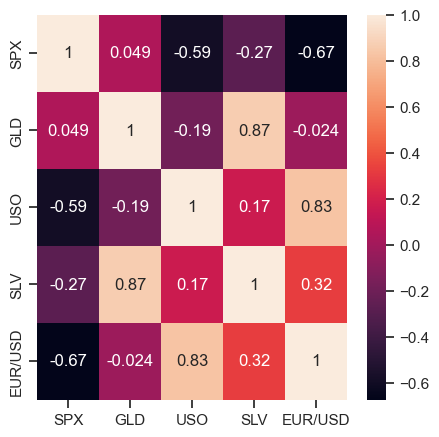

In [11]:
correlations = df.select_dtypes(include=np.number).corr(method='pearson')
# Spécifie que nous utilisons la méthode de Pearson pour calculer les corrélations.
f, ax = plt.subplots(figsize = (5, 5))
# Crée une figure (f) et des axes (ax) avec une taille de 5x5 pouces.
sns.heatmap(correlations, annot = True)
#Utilise la bibliothèque Seaborn pour créer une carte thermique (heatmap) de la matrice de corrélation. L'argument annot=True affiche les valeurs des coefficients de corrélation dans chaque cellule de la heatmap.

In [12]:
df['GLD'].describe()

count    2290.000000
mean      122.732875
std        23.283346
min        70.000000
25%       109.725000
50%       120.580002
75%       132.840004
max       184.589996
Name: GLD, dtype: float64

C:\Users\BADROM\AppData\Local\Temp\ipykernel_1700\3736964373.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

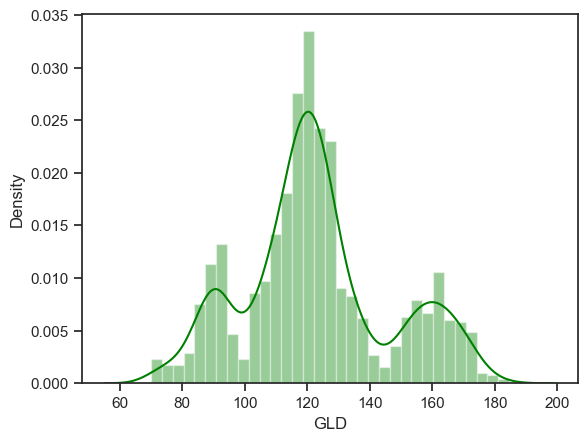

In [13]:
sns.distplot(df['GLD'],color='green')

In [14]:
X = df.drop(['Date','GLD'],axis=1)
Y = df['GLD']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size =0.2, random_state=2)

In [15]:
from sklearn.linear_model import LinearRegression
profit_model = LinearRegression()

# Entraînement du modèle
profit_model.fit(X_train, Y_train)

# Prédictions
y_train_pred = profit_model.predict(X_train)
y_test_pred = profit_model.predict(X_test)
print("\n=== ÉVALUATION DU MODÈLE DE RÉGRESSION LINÉAIRE MULTIPLE ===")
print("\nCoefficients du modèle:")
for feature, coef in zip(X, profit_model.coef_):
    print(f"  {feature}: {coef:.2f}")

print(f"\nIntercept: {profit_model.intercept_:.2f}")


=== ÉVALUATION DU MODÈLE DE RÉGRESSION LINÉAIRE MULTIPLE ===

Coefficients du modèle:
  SPX: 0.01
  USO: -0.26
  SLV: 3.18
  EUR/USD: -9.00

Intercept: 67.46


In [16]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mse_train = mean_squared_error(Y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(Y_train, y_train_pred)
r2_train = r2_score(Y_train, y_train_pred)

print(f"Erreur quadratique moyenne (MSE): {mse_train:.2f}")
print(f"Racine de l'erreur quadratique moyenne (RMSE): {rmse_train:.2f}")
print(f"Erreur absolue moyenne (MAE): {mae_train:.2f}")
print(f"Coefficient de détermination (R²): {r2_train:.4f}")

print("\n--- Performances sur l'ensemble de test ---")
mse_test = mean_squared_error(Y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(Y_test, y_test_pred)
r2_test = r2_score(Y_test, y_test_pred)

print(f"Erreur quadratique moyenne (MSE): {mse_test:.2f}")
print(f"Racine de l'erreur quadratique moyenne (RMSE): {rmse_test:.2f}")
print(f"Erreur absolue moyenne (MAE): {mae_test:.2f}")
print(f"Coefficient de détermination (R²): {r2_test:.4f}")

Erreur quadratique moyenne (MSE): 62.69
Racine de l'erreur quadratique moyenne (RMSE): 7.92
Erreur absolue moyenne (MAE): 5.94
Coefficient de détermination (R²): 0.8851

--- Performances sur l'ensemble de test ---
Erreur quadratique moyenne (MSE): 70.79
Racine de l'erreur quadratique moyenne (RMSE): 8.41
Erreur absolue moyenne (MAE): 5.91
Coefficient de détermination (R²): 0.8658


In [17]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100)
regressor.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
test_data_pred = regressor.predict(X_test)
print(test_data_pred)

[168.49399906  82.05099975 116.05799989 127.45600061 120.74200123
 154.71279753 150.3385975  126.14790062 117.28919884 125.98410056
 116.57410094 172.30390092 141.42179814 167.97579863 115.0497
 117.81970078 140.03140306 170.35780154 159.04290249 159.32499918
 155.1228002  125.25530021 175.50439998 156.81960465 125.25780012
  93.61999987  77.68770003 120.50150001 119.15239935 167.58169966
  88.21850027 125.07089959  91.03260082 117.72180005 121.11319917
 137.40280033 115.30550136 115.36940048 148.73939956 106.88900114
 104.82600288  87.20829797 126.56180046 118.10480034 153.81739872
 119.41420003 108.40049979 108.18159884  93.10550028 127.08769781
  74.93360035 113.66029933 121.20540014 111.40049917 118.98529911
 120.63619932 159.72699947 168.91750096 146.69259611  85.84539877
  94.29500049  86.87609855  90.55830037 119.00970081 126.43530095
 127.67360054 169.73880013 122.24839918 117.57289882  98.79050048
 168.71380161 142.78749898 131.82020214 121.19300248 120.71749968
 119.73590055 

In [19]:
from sklearn import metrics
metrics.r2_score(Y_test, test_data_pred)

0.9885234526067347

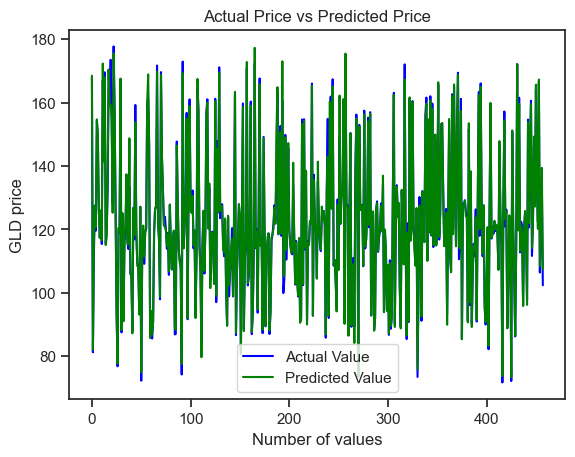

In [20]:


Y_test = list(Y_test)
plt.plot(Y_test, color = 'blue', label ="Actual Value")
plt.plot(test_data_pred, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD price')
plt.legend()
plt.show()

### Traitement des valeurs aberrantes (Outliers) par la moyenne

Nous allons identifier les valeurs aberrantes pour chaque colonne numérique en utilisant la méthode IQR (InterQuartile Range) et les remplacer par la moyenne de leur colonne respective.

In [21]:
# Créer une copie du DataFrame pour travailler dessus
df_cleaned = df.copy()

# Itérer sur chaque colonne numérique pour détecter et remplacer les outliers

# Calculer Q1 (25ème percentile) et Q3 (75ème percentile)
Q1 = df_cleaned['GLD'].quantile(0.25)
Q3 = df_cleaned['GLD'].quantile(0.75)
IQR = Q3 - Q1

    # Définir les limites pour les outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

    # Calculer la moyenne de la colonne
mean_value = df_cleaned['GLD'].mean()

    # Remplacer les outliers par la moyenne
df_cleaned.loc[(df_cleaned['GLD'] < lower_bound) | (df_cleaned['GLD'] > upper_bound), 'GLD'] = mean_value

print("DataFrame après remplacement des outliers par la moyenne:")
display(df_cleaned.head())


DataFrame après remplacement des outliers par la moyenne:


,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [24]:
import joblib
joblib.dump(profit_model, "model.pkl")

['model.pkl']